<a href="https://colab.research.google.com/github/helelelelena/helelelelena.github.io/blob/main/appm5560.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#hw1!

Simulation Assignment 1: Coupled Inequalities

Let $X$, $Y$, and $Z$ be independent $\mathrm{Uniform}[0,1]$ random variables.

(a) Analytical Calculation

Analytically compute the probability that both of the following inequalities hold:

$X^2 + Y^2 < Z$ and $Z^2 > XY$.

Describe the region of the unit cube $[0,1]^3$ satisfying both inequalities and set up the appropriate integrals.

(b) Monte Carlo Simulation

Estimate the same probability using a Monte Carlo simulation.

Compare the Monte Carlo estimate with the analytical probability obtained in part (a).

Create a plot showing the Monte Carlo probability estimate as a function of sample size $N$.

- Use a **logarithmic scale** for the horizontal ($N$) axis.
- Draw the **analytical probability** from part (a) as a horizontal reference line.
- Label the axes and include a legend.

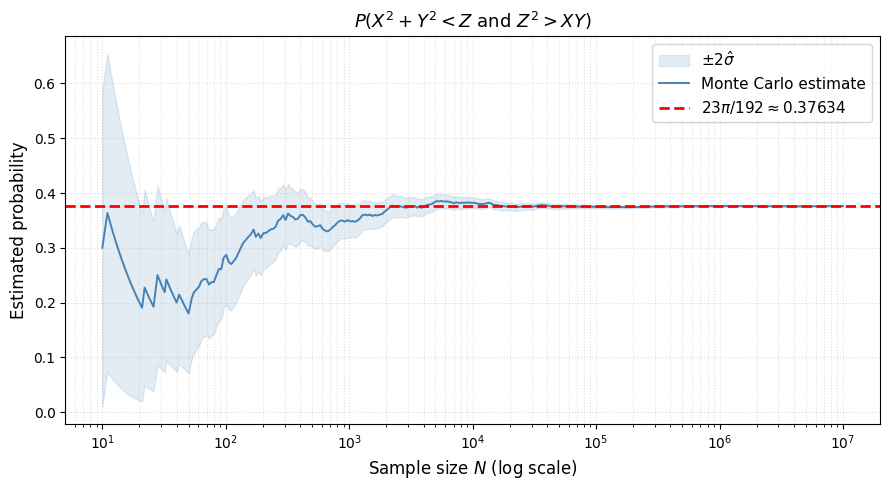

Final estimate (N=10,000,000): 0.37606
Exact value:                  0.37634


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# value from a
p_exact = 23 * np.pi / 192

# Monte Carlo
rng = np.random.default_rng(42)
N_MAX = 10_000_000

X = rng.uniform(size=N_MAX)
Y = rng.uniform(size=N_MAX)
Z = rng.uniform(size=N_MAX)

hits = (X**2 + Y**2 < Z) & (Z**2 > X * Y)

checkpoints = np.unique(np.round(np.logspace(1, np.log10(N_MAX), 300)).astype(int))
estimates = np.cumsum(hits)[checkpoints - 1] / checkpoints
serror = np.sqrt(estimates * (1 - estimates) / checkpoints)

fig, ax = plt.subplots(figsize=(9, 5))

ax.fill_between(checkpoints, estimates - 2*se, estimates + 2*se,
                alpha=0.15, color="steelblue", label=r"$\pm 2\hat{\sigma}$")
ax.semilogx(checkpoints, estimates, color="steelblue", lw=1.4,
            label="Monte Carlo estimate")
ax.axhline(p_exact, color="red", lw=2, ls="--",
           label=rf"$23\pi/192 \approx {p_exact:.5f}$")

ax.set_xlabel("Sample size $N$ (log scale)", fontsize=12)
ax.set_ylabel("Estimated probability", fontsize=12)
ax.set_title(r"$P(X^2+Y^2 < Z \text{ and } Z^2 > XY)$", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, which="both", ls=":", alpha=0.4)
plt.tight_layout()
plt.savefig("part_b.png", dpi=150)
plt.show()

print(f"Final estimate (N={N_MAX:,}): {estimates[-1]:.5f}")
print(f"Exact value:                  {p_exact:.5f}")

#hw2!

lambda = 0.5
Theoretical acceptance rate = 0.6796
Empirical acceptance rate   = 0.6750

lambda = 0.2
Theoretical acceptance rate = 0.4349
Empirical acceptance rate   = 0.4398


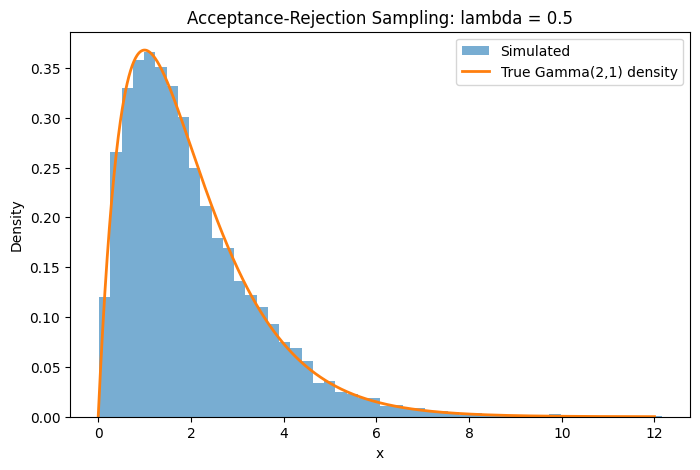

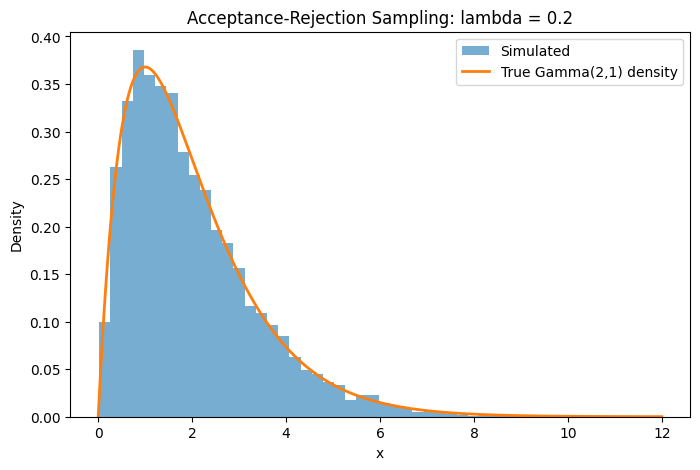

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

def f(x):
    return x * np.exp(-x)

def rejection_sample(n, lam, c):
    accepted = []
    proposals = 0

    start = time.perf_counter()

    while len(accepted) < n:
        # 1. generate X ~ Exp(lam) by inversion
        W = np.random.uniform(0, 1)
        X = -np.log(W) / lam

        # 2. generate U ~ Uniform(0,1)
        U = np.random.uniform(0, 1)

        # 3. acceptance probability f(X)/(c*g(X))
        gX = lam * np.exp(-lam * X)
        accept_prob = f(X) / (c * gX)

        # 4. accept or reject
        if U < accept_prob:
            accepted.append(X)

        proposals += 1

    elapsed = time.perf_counter() - start

    accepted = np.array(accepted)

    # empirical acceptance fraction
    acceptance_fraction = n / proposals

    # mean time per accepted sample
    time_per_accept = elapsed / n

    return accepted, acceptance_fraction, time_per_accept, proposals

N = 10_000

lam1 = 0.5
c1 = 4 / np.e

lam2 = 0.2
c2 = 1 / (0.16 * np.e)

samples1, acc1, time1, props1 = rejection_sample(N, lam1, c1)
samples2, acc2, time2, props2 = rejection_sample(N, lam2, c2)

theory1 = 1 / c1
theory2 = 1 / c2


print("lambda = 0.5")
print(f"Theoretical acceptance rate = {theory1:.4f}")
print(f"Empirical acceptance rate   = {acc1:.4f}")
print()

print("lambda = 0.2")
print(f"Theoretical acceptance rate = {theory2:.4f}")
print(f"Empirical acceptance rate   = {acc2:.4f}")

# plot lambda 0.5
x = np.linspace(0, 12, 1000)

plt.figure(figsize=(8, 5))
plt.hist(samples1, bins=50, density=True, alpha=0.6, label="Simulated")
plt.plot(x, f(x), linewidth=2, label="True Gamma(2,1) density")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Acceptance-Rejection Sampling: lambda = 0.5")
plt.legend()
plt.show()


# plot lambda 0.5

plt.figure(figsize=(8, 5))
plt.hist(samples2, bins=50, density=True, alpha=0.6, label="Simulated")
plt.plot(x, f(x), linewidth=2, label="True Gamma(2,1) density")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Acceptance-Rejection Sampling: lambda = 0.2")
plt.legend()
plt.show()

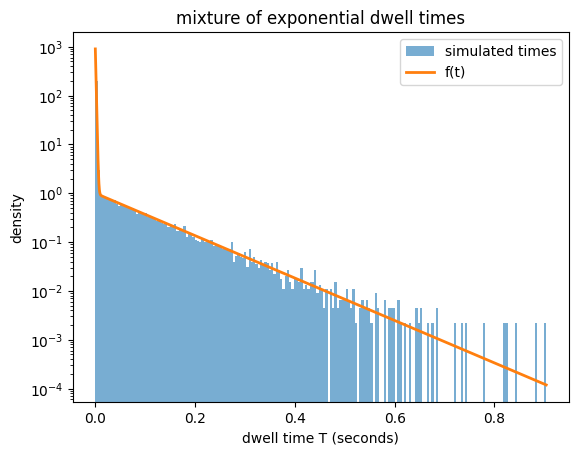

In [ ]:
# Generate 10**5 dwell times by composition. Plot the normalized histogram on semilog vertical
# axes with f (t) overlaid, so that both components are visible. Report the empirical mean
# and the empirical P(T > 50 ms) against theory.

import numpy as np
import matplotlib.pyplot as plt

N=10**5

# parameters
a = 0.9
lf = 1000
ls = 10

bern = np.random.binomial(n=1, p=a, size=N)

lamb = np.where(bern==1, lf, ls)
W = np.random.uniform(0, 1, size=N)
T = -np.log(W) / lamb


def f(t):
    return (a * lf * np.exp(-lf * t)
            + (1 - a) * ls * np.exp(-ls * t))

t = np.linspace(0, T.max(), 1000)

plt.hist(T, bins=200, density=True, alpha=0.6, label="simulated times")

# theoretical
plt.plot(t, f(t), linewidth=2, label="f(t)")

plt.yscale("log")

plt.xlabel("dwell time T (seconds)")
plt.ylabel("density")
plt.title("mixture of exponential dwell times")
plt.legend()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 10**5

U = np.random.uniform(0, 1, N)
Z = 1 - np.sqrt(1 - U)

sample_mean = np.mean(Z)
theoretical_mean = 1/3

print("Sample mean:", sample_mean)
print("Theoretical mean:", theoretical_mean)

Sample mean: 0.3322854618739424
Theoretical mean: 0.3333333333333333


In [ ]:
# Simulate the growth process at μ = 1 out to N = 10**4 for R = 10**3 independent realizations,
# vectorizing across realizations. By this I mean that the update at step n must draw a
# single length R vector of Bernoulli variates: a loop over realizations wrapped around a loop
# over steps is 107 interpreted iterations and will not finish in a sitting. Plot the normalized
# histogram of z = C/N with h(z) overlaid, and report the empirical mean and the empirical
# ratio of standard deviation to mean against your answers in part (a). Report the smallest
# and largest core you saw, and comment in two or three sentences on what the average core
# size does and does not tell you about a single network

import numpy as np
import matplotlib.pyplot as plt

N = 10**4
R = 10**3

rng = np.random.default_rng(42)

# C(3) = 1
C = np.ones(R, dtype=int)

# Grow from n = 3 to n = N
for n in range(3, N):
    # prob
    p = C / n

    # vector bern
    increment = rng.binomial(1, p, size=R)

    # Update all R realizations
    C += increment

# z = C/N for each realization
z = C / N

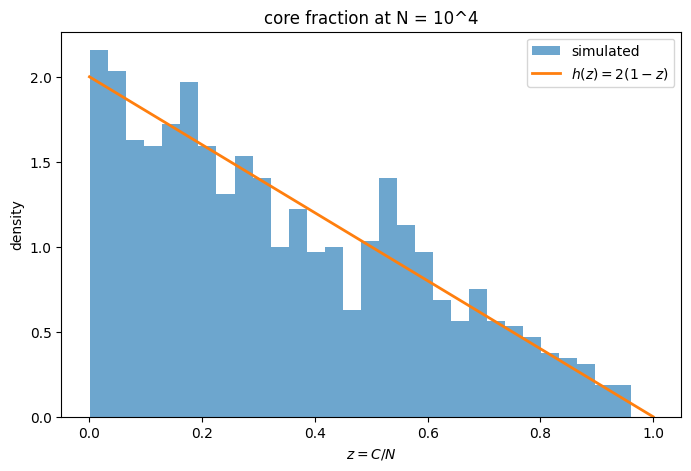

In [ ]:
x = np.linspace(0, 1, 500)
h = 2 * (1 - x)

plt.figure(figsize=(8, 5))

plt.hist(z, bins=30, density=True, alpha=0.65,
         label="simulated")

plt.plot(x, h, linewidth=2,
         label=r"$h(z)=2(1-z)$")

plt.xlabel(r"$z=C/N$")
plt.ylabel("density")
plt.title("core fraction at N = 10^4")
plt.legend()

plt.show()

In [ ]:
# Statistics
empirical_mean = np.mean(z)
empirical_sd = np.std(z, ddof=1)
empirical_ratio = empirical_sd / empirical_mean

print("Mean")
print("  theoretical:", 1/3)
print("  empirical:  ", empirical_mean)

print("\nSD / mean")
print("  theoretical:", 1/np.sqrt(2))
print("  empirical:  ", empirical_ratio)

print("\nCore size range")
print("  average:", C.mean())
print("  smallest:", C.min())
print("  largest: ", C.max())

Mean
  theoretical: 0.3333333333333333
  empirical:   0.34008889999999997

SD / mean
  theoretical: 0.7071067811865475
  empirical:   0.7120250773708783

Core size range
  average: 3400.889
  smallest: 15
  largest:  9610


beta_1 = 0.5064
beta_2 = 0.7405

 t        S2(t)       S1(t)^2
  100    0.347450    0.267237
 1000    0.065500    0.031400
10000    0.011350    0.003042


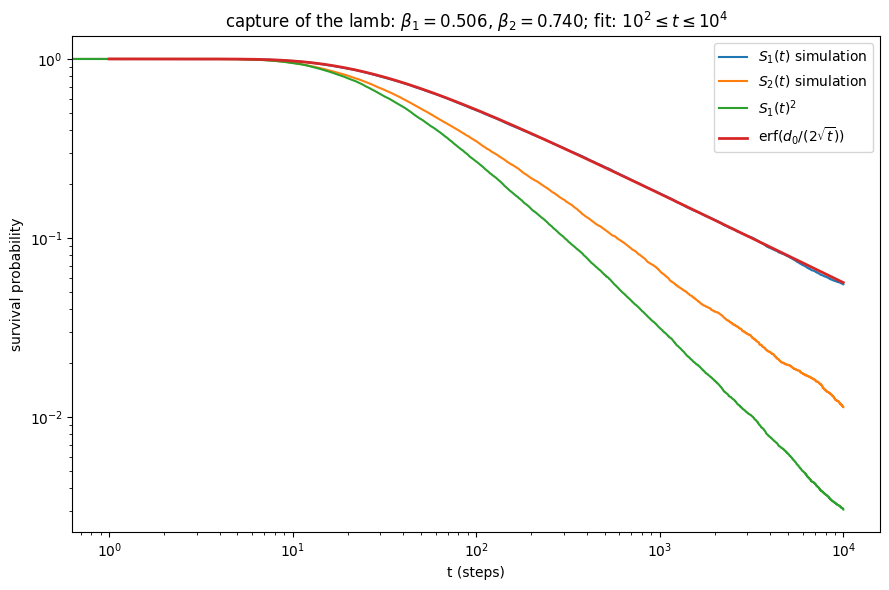

In [1]:
import numpy as np
import matplotlib.pyplot as plt



R = 2 * 10**4
Tmax = 10**4
d0 = 10

rng = np.random.default_rng(12345)

# one lion
lamb1 = np.zeros(R, dtype=np.int32)
lion1 = np.full(R, d0, dtype=np.int32)

alive1 = np.ones(R, dtype=bool)

S1 = np.empty(Tmax + 1)
S1[0] = 1.0

for t in range(1, Tmax + 1):

    idx = np.flatnonzero(alive1)

    lamb1[idx] += 2 * rng.integers(0, 2, size=len(idx)) - 1

    lion1[idx] += 2 * rng.integers(0, 2, size=len(idx)) - 1

    captured = (lamb1[idx] == lion1[idx])

    alive1[idx[captured]] = False

    S1[t] = alive1.mean()


# two lions
lamb2 = np.zeros(R, dtype=np.int32)

lion2a = np.full(R, d0, dtype=np.int32)
lion2b = np.full(R, d0, dtype=np.int32)

alive2 = np.ones(R, dtype=bool)

S2 = np.empty(Tmax + 1)
S2[0] = 1.0

for t in range(1, Tmax + 1):

    idx = np.flatnonzero(alive2)

    # Lamb
    lamb2[idx] += 2 * rng.integers(0, 2, size=len(idx)) - 1

    # Lion 1
    lion2a[idx] += 2 * rng.integers(0, 2, size=len(idx)) - 1

    # Lion 2
    lion2b[idx] += 2 * rng.integers(0, 2, size=len(idx)) - 1

    # Capture if either lion meets the lamb
    captured = (
        (lion2a[idx] == lamb2[idx])
        |
        (lion2b[idx] == lamb2[idx])
    )

    alive2[idx[captured]] = False

    S2[t] = alive2.mean()


times = np.arange(Tmax + 1)

fit_mask = (
    (times >= 10**2)
    & (times <= 10**4)
    & (S1 > 0)
    & (S2 > 0)
)

slope1, intercept1 = np.polyfit(
    np.log(times[fit_mask]),
    np.log(S1[fit_mask]),
    1
)

slope2, intercept2 = np.polyfit(
    np.log(times[fit_mask]),
    np.log(S2[fit_mask]),
    1
)

beta1 = -slope1
beta2 = -slope2

t_theory = np.logspace(0, 4, 500)

S1_theory = np.array([
    __import__("math").erf(
        d0 / (2 * np.sqrt(t))
    )
    for t in t_theory
])

print(f"beta_1 = {beta1:.4f}")
print(f"beta_2 = {beta2:.4f}")


selected_times = [10**2, 10**3, 10**4]

print("\n t        S2(t)       S1(t)^2")
for t in selected_times:
    print(
        f"{t:5d}    "
        f"{S2[t]:.6f}    "
        f"{S1[t]**2:.6f}"
    )

plt.figure(figsize=(9, 6))

positive1 = S1 > 0
positive2 = S2 > 0

plt.loglog(
    times[positive1],
    S1[positive1],
    label=r"$S_1(t)$ simulation"
)

plt.loglog(
    times[positive2],
    S2[positive2],
    label=r"$S_2(t)$ simulation"
)

plt.loglog(
    times[positive1],
    S1[positive1]**2,
    label=r"$S_1(t)^2$"
)

plt.loglog(
    t_theory,
    S1_theory,
    linewidth=2,
    label=r"$\mathrm{erf}(d_0/(2\sqrt{t}))$"
)

plt.xlabel("t (steps)")
plt.ylabel("survival probability")

plt.title(
    rf"capture of the lamb: "
    rf"$\beta_1={beta1:.3f}$, "
    rf"$\beta_2={beta2:.3f}$; "
    rf"fit: $10^2\leq t\leq10^4$"
)

plt.legend()
plt.tight_layout()
plt.show()